In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir('D:/thesis_code/keypoint_matcher')

from config import config
from utils import logger
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torch.nn.functional import relu
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.cuda.empty_cache()

In [3]:
# def dual_conv(in_channel, out_channel):
#     return nn.Sequential(
#         nn.Conv2d(in_channel, out_channel, kernel_size=3, padding=1),
#         nn.ReLU(inplace=True),
#         nn.Conv2d(out_channel, out_channel, kernel_size=3, padding=1),
#         nn.ReLU(inplace=True),
#     )
#
#
# class Unet(nn.Module):
#     def __init__(self):
#         super().__init__()
#
#         self.dwn_conv1 = dual_conv(1, 64)
#         self.dwn_conv2 = dual_conv(64, 128)
#         self.dwn_conv3 = dual_conv(128, 256)
#         self.dwn_conv4 = dual_conv(256, 512)
#         self.dwn_conv5 = dual_conv(512, 1024)
#
#         self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
#
#         self.trans1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
#         self.up_conv1 = dual_conv(1024, 512)
#         self.trans2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
#         self.up_conv2 = dual_conv(512, 256)
#         self.trans3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
#         self.up_conv3 = dual_conv(256, 128)
#         self.trans4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
#         self.up_conv4 = dual_conv(128, 64)
#
#         self.out = nn.Conv2d(64, 1, kernel_size=1)
#
#     def forward(self, image):
#         x1 = self.dwn_conv1(image)
#         x2 = self.maxpool(x1)
#         x3 = self.dwn_conv2(x2)
#         x4 = self.maxpool(x3)
#         x5 = self.dwn_conv3(x4)
#         x6 = self.maxpool(x5)
#         x7 = self.dwn_conv4(x6)
#         x8 = self.maxpool(x7)
#         x9 = self.dwn_conv5(x8)
#
#         x = self.trans1(x9)
#         x = self.up_conv1(torch.cat([x, x7], 1))
#
#         x = self.trans2(x)
#         x = self.up_conv2(torch.cat([x, x5], 1))
#
#         x = self.trans3(x)
#         x = self.up_conv3(torch.cat([x, x3], 1))
#
#         x = self.trans4(x)
#         x = self.up_conv4(torch.cat([x, x1], 1))
#
#         x = self.out(x)  # Raw heatmap logits
#         x = torch.sigmoid(x)  # Convert to [0,1] range for probability
#
#         return x
#
#
# def generate_gaussian_heatmap(size, center, sigma=5):
#     x = torch.arange(0, size, 1, dtype=torch.float32).view(-1, 1).expand(size, size)
#     y = torch.arange(0, size, 1, dtype=torch.float32).view(1, -1).expand(size, size)
#
#     x0, y0 = center
#     heatmap = torch.exp(-((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2))
#
#     return heatmap
#
#
# # Example usage
# image = torch.rand((1, 1, 128, 128))
# target_keypoint = (64, 64)
# heatmap_gt = generate_gaussian_heatmap(
#     128,
#     target_keypoint
# ).unsqueeze(0).unsqueeze(0)
# # Shape: (1, 1, 128, 128)
#
#
# model = Unet()
# predicted_heatmap = model(image)
#
# print(predicted_heatmap.shape)
# # ✅ Should be torch.Size([1, 1, 128, 128])

In [4]:
PATCH_SIZE = config.image.patch_size
batch_size = 2

In [17]:
from src.model_unet import (
    MatcherModel,
    generate_gaussian_heatmap,
    generate_gaussian_heatmap1,
)

matcher_model = MatcherModel()

ref_patches = torch.rand((batch_size, 1, PATCH_SIZE, PATCH_SIZE))
tar_patches = torch.rand((batch_size, 1, PATCH_SIZE, PATCH_SIZE))
references = torch.rand((batch_size, 2))
estimates = torch.rand((batch_size, 2))

predicted_heatmap, peak_coords = matcher_model(
    ref_patches,
    tar_patches,
    references,
    estimates
)

print(f'{predicted_heatmap.shape=}')
print(f'{peak_coords.shape=}')

ref_patches.shape=torch.Size([2, 32, 32, 32])
references.shape=torch.Size([2, 1, 32, 32])
x.shape=torch.Size([2, 66, 32, 32])
predicted_heatmap.shape=torch.Size([2, 1, 32, 32])
peak_coords.shape=torch.Size([2, 2])


heatmap_gt.shape=torch.Size([32, 32])


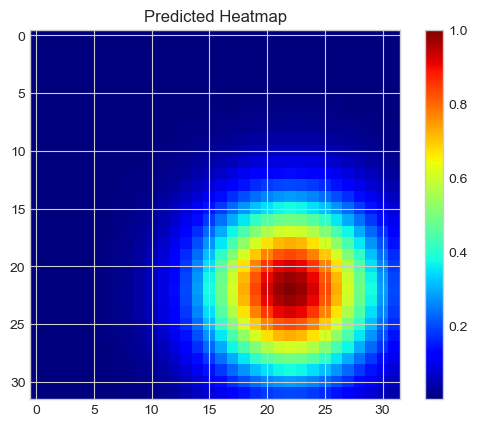

In [20]:
target_keypoint = (22, 22)

heatmap_gt = generate_gaussian_heatmap1(
    PATCH_SIZE,
    center=target_keypoint,
    sigma=5,
)

print(f'{heatmap_gt.shape=}')

# Visualize heatmap
plt.imshow(heatmap_gt, cmap='jet')
plt.colorbar()
plt.title("Predicted Heatmap")
plt.show()

In [19]:
# Example usage for a batch of 3 heatmaps
centers = torch.tensor([[30.0, 30.0], [10.0, 50.0]])
heatmaps = generate_gaussian_heatmap(PATCH_SIZE, centers, sigma=5)
print(heatmaps.shape)  # Should print: torch.Size([3, 64, 64])

torch.Size([2, 32, 32])
